<a href="https://colab.research.google.com/github/avindumihisara0229-code/ErgoSense/blob/Ramzan/Drowsiness_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install necessary libraries
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.14 opencv-python-headless tensorflow scikit-learn matplotlib seaborn numpy pandas tqdm

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.7 MB)


In [3]:
# Suppress protobuf warnings
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='google.protobuf')

# Import all required libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mediapipe as mp
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import pickle
from tqdm import tqdm

#TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f"MediaPipe version: {mp.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print("All libraries imported successfully")

MediaPipe version: 0.10.14
TensorFlow version: 2.19.0
All libraries imported successfully


# Connect Google Drive

In [4]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Define dataset paths
DATASET_PATH = '/content/drive/MyDrive/dataset_new'
TRAIN_PATH = os.path.join(DATASET_PATH, 'train')
TEST_PATH = os.path.join(DATASET_PATH, 'test')

# Verify dataset exists
if os.path.exists(DATASET_PATH):
    print("Dataset found")
    print("\nTrain folders:", os.listdir(TRAIN_PATH))
    print("Test folders:", os.listdir(TEST_PATH))
else:
    print("ERROR: Dataset not found. Please upload dataset to Google Drive.")

Dataset found

Train folders: ['no_yawn', 'yawn', 'Open', 'Closed']
Test folders: ['yawn', 'Closed', 'Open', 'no_yawn']


# EYE STATE DETECTION (CNN)

## Load and preprocess Eye images

In [6]:
def load_eye_images(base_path, img_size=(64, 64)):
    """Load eye images (Open/Closed) and prepare for CNN"""
    images = []
    labels = []

    # 0 = Open (Alert), 1 = Closed (Drowsy)
    eye_folders = {'Open': 0, 'Closed': 1}

    for folder_name, label in eye_folders.items():
        folder_path = os.path.join(base_path, folder_name)

        if not os.path.exists(folder_path):
            print(f"Warning: {folder_name} folder not found")
            continue

        print(f"Loading {folder_name} images.")
        image_files = [f for f in os.listdir(folder_path) if not f.startswith('.')]

        for img_file in tqdm(image_files):
            img_path = os.path.join(folder_path, img_file)

            # Read and resize image
            img = cv2.imread(img_path)
            if img is None:
                continue

            # Convert to RGB and resize
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)

            images.append(img)
            labels.append(label)

    # Convert to numpy arrays and normalize
    images = np.array(images, dtype='float32') / 255.0
    labels = np.array(labels)

    return images, labels

# Load training and test eye images
print("Loading TRAINING eye images")
X_train_eye_full, y_train_eye_full = load_eye_images(TRAIN_PATH)

print("\nLoading TEST eye images (held out — never seen during training)")
X_test_eye, y_test_eye = load_eye_images(TEST_PATH)

# Split training data into train (80%) and validation (20%)
# This prevents data leakage — test set stays truly unseen

X_train_eye, X_val_eye, y_train_eye, y_val_eye = train_test_split(
    X_train_eye_full, y_train_eye_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_eye_full  # Keep class balance in both splits
)

print(f"\n{'='*50}")
print("DATASET SPLIT SUMMARY")
print(f"{'='*50}")
print(f"Training set:   {X_train_eye.shape[0]} images")
print(f"  Open: {np.sum(y_train_eye == 0)} | Closed: {np.sum(y_train_eye == 1)}")
print(f"Validation set: {X_val_eye.shape[0]} images")
print(f"  Open: {np.sum(y_val_eye == 0)} | Closed: {np.sum(y_val_eye == 1)}")
print(f"Test set:       {X_test_eye.shape[0]} images (HELD OUT)")
print(f"  Open: {np.sum(y_test_eye == 0)} | Closed: {np.sum(y_test_eye == 1)}")

Loading TRAINING eye images
Loading Open images.


100%|██████████| 617/617 [00:17<00:00, 35.87it/s] 


Loading Closed images.


100%|██████████| 617/617 [00:19<00:00, 32.11it/s] 



Loading TEST eye images (held out — never seen during training)
Loading Open images.


100%|██████████| 109/109 [00:02<00:00, 39.32it/s]


Loading Closed images.


100%|██████████| 109/109 [00:02<00:00, 41.75it/s] 


DATASET SPLIT SUMMARY
Training set:   987 images
  Open: 493 | Closed: 494
Validation set: 247 images
  Open: 124 | Closed: 123
Test set:       218 images (HELD OUT)
  Open: 109 | Closed: 109


## Build CNN Model for Eye Classification

In [7]:
# Build CNN model
eye_model = Sequential([
    # Input layer
    keras.Input(shape=(64, 64, 3)),

    # First convolutional block
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Third convolutional block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten and dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification: Open(0) or Closed(1)
])

# Compile model
eye_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Eye Classification CNN Model:")
eye_model.summary()

Eye Classification CNN Model:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Train Eye Classification Model

In [8]:
from tensorflow.keras.optimizers import Adam

eye_model.compile(
    optimizer=Adam(learning_rate=0.001),   # Back to default
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("Model compiled with default Adam (lr=0.001)")

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/drowsiness_models/best_eye_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured:")
print("  - EarlyStopping (patience=5, restore_best_weights=True)")
print("  - ModelCheckpoint (save_best_only=True)")

print("\n" + "="*50)
print("Training Eye Classification Model")
print("="*50)

history = eye_model.fit(
    X_train_eye, y_train_eye,               # Raw images
    validation_data=(X_val_eye, y_val_eye),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Report
best_epoch = np.argmin(history.history['val_loss']) + 1
total_epochs = len(history.history['val_loss'])
print(f"\nTraining completed!")
print(f"  Ran {total_epochs} epochs (max 30)")
print(f"  Best epoch: {best_epoch}")
print(f"  Best val_loss: {min(history.history['val_loss']):.4f}")
print(f"  Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
if total_epochs < 30:
    print(f"  Early stopping triggered at epoch {total_epochs} (patience=5)")

Model compiled with default Adam (lr=0.001)
Callbacks configured:
  - EarlyStopping (patience=5, restore_best_weights=True)
  - ModelCheckpoint (save_best_only=True)

Training Eye Classification Model
Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6961 - loss: 0.5830
Epoch 1: val_loss improved from None to 0.19732, saving model to /content/drive/MyDrive/drowsiness_models/best_eye_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/drowsiness_models/best_eye_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.7974 - loss: 0.4413 - val_accuracy: 0.9555 - val_loss: 0.1973
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9127 - loss: 0.2425
Epoch 2: val_loss improved from 0.19732 to 0.12766, saving model to /content/drive/MyDrive/drowsiness_models/best_eye_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/drowsiness_models/best_eye_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - accuracy: 0.923

# Test Model before saving

In [9]:
# ========================================
# TEST MODEL BEFORE SAVING
# ========================================
print("\n" + "="*60)
print("TESTING MODEL ON SAMPLE IMAGES - VERIFY IT WORKS")
print("="*60)

correct = 0
total = 10

for i in range(total):
    idx = np.random.randint(0, len(X_test_eye))
    test_img = X_test_eye[idx]
    true_label = y_test_eye[idx]

    # Predict
    pred_value = eye_model.predict(np.expand_dims(test_img, axis=0), verbose=0)[0][0]
    pred_label = 1 if pred_value > 0.5 else 0

    true_str = "CLOSED" if true_label == 1 else "OPEN"
    pred_str = "CLOSED" if pred_label == 1 else "OPEN"

    if pred_label == true_label:
        match = " CORRECT"
        correct += 1
    else:
        match = " WRONG"

    print(f"Test {i+1}: True={true_str:6} | Pred={pred_str:6} (value={pred_value:.3f}) | {match}")

accuracy = (correct / total) * 100
print(f"\nSample Accuracy: {correct}/{total} = {accuracy:.0f}%")

if accuracy < 70:
    print("\n  WARNING: Model accuracy is LOW")
    print("  DO NOT save this model - retrain with more epochs")
else:
    print(f"\n Model looks good Accuracy: {accuracy:.0f}%")


TESTING MODEL ON SAMPLE IMAGES - VERIFY IT WORKS
Test 1: True=OPEN   | Pred=OPEN   (value=0.000) |  CORRECT
Test 2: True=OPEN   | Pred=OPEN   (value=0.000) |  CORRECT
Test 3: True=CLOSED | Pred=CLOSED (value=1.000) |  CORRECT
Test 4: True=OPEN   | Pred=OPEN   (value=0.000) |  CORRECT
Test 5: True=OPEN   | Pred=OPEN   (value=0.000) |  CORRECT
Test 6: True=CLOSED | Pred=CLOSED (value=1.000) |  CORRECT
Test 7: True=OPEN   | Pred=OPEN   (value=0.000) |  CORRECT
Test 8: True=CLOSED | Pred=CLOSED (value=0.999) |  CORRECT
Test 9: True=OPEN   | Pred=OPEN   (value=0.000) |  CORRECT
Test 10: True=CLOSED | Pred=CLOSED (value=1.000) |  CORRECT

Sample Accuracy: 10/10 = 100%

 Model looks good Accuracy: 100%


## Eye CNN loss curves

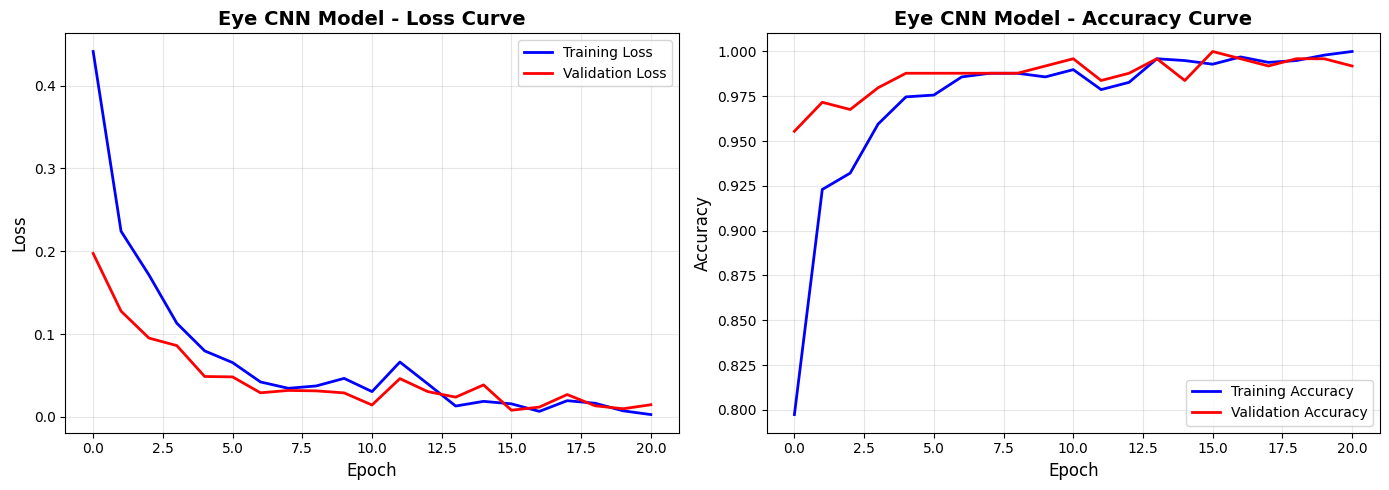


Best Epoch: 16
Best Validation Loss: 0.0080
Best Validation Accuracy: 1.0000


In [10]:
# Visualize Eye CNN Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Eye CNN Model - Loss Curve', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Eye CNN Model - Accuracy Curve', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"\nBest Epoch: {best_epoch}")
print(f"Best Validation Loss: {min(history.history['val_loss']):.4f}")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")

## Evaluate Eye Open/Closed Model Performance

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
EYE CLASSIFICATION MODEL PERFORMANCE
Test Accuracy: 96.79%

Classification Report:
              precision    recall  f1-score   support

        Open       0.97      0.96      0.97       109
      Closed       0.96      0.97      0.97       109

    accuracy                           0.97       218
   macro avg       0.97      0.97      0.97       218
weighted avg       0.97      0.97      0.97       218



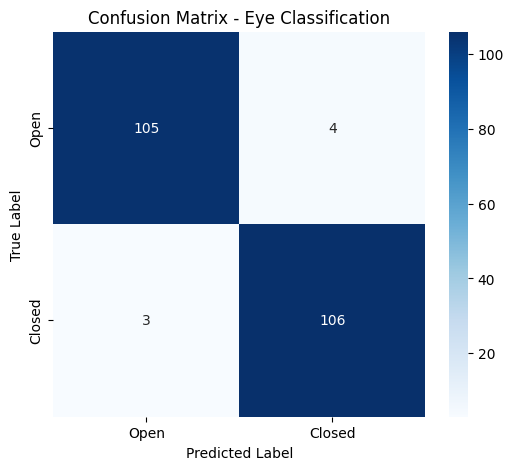

In [11]:
# Evaluate model
y_pred_eye_prob = eye_model.predict(X_test_eye)
y_pred_eye = (y_pred_eye_prob > 0.5).astype(int).flatten()

eye_accuracy = accuracy_score(y_test_eye, y_pred_eye)

print("="*50)
print("EYE CLASSIFICATION MODEL PERFORMANCE")
print("="*50)
print(f"Test Accuracy: {eye_accuracy * 100:.2f}%")
print("="*50)

print("\nClassification Report:")
print(classification_report(y_test_eye, y_pred_eye, target_names=['Open', 'Closed']))

# Confusion Matrix
cm_eye = confusion_matrix(y_test_eye, y_pred_eye)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_eye, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Open', 'Closed'],
            yticklabels=['Open', 'Closed'])
plt.title('Confusion Matrix - Eye Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# YAWN DETECTION (MediaPipe+MAR)

## Initialize MediaPipe for Yawn Detection

In [18]:
# Initialize MediaPipe Face Mesh
from mediapipe.python.solutions import face_mesh

face_mesh_detector = face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.3
)

# Define mouth landmarks for MAR calculation
MOUTH = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 308, 324, 318, 402, 317, 14, 87, 178, 88]

print("MediaPipe Face Mesh initialized for yawn detection")

MediaPipe Face Mesh initialized for yawn detection


## Define MAR Calculation Function

In [19]:
def calculate_distance(point1, point2):
    """Calculate Euclidean distance between two points"""
    return np.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

def calculate_mar(mouth_landmarks):
    """Calculate Mouth Aspect Ratio (MAR)"""
    # Vertical distances
    vertical1 = calculate_distance(mouth_landmarks[2], mouth_landmarks[10])
    vertical2 = calculate_distance(mouth_landmarks[4], mouth_landmarks[8])
    vertical3 = calculate_distance(mouth_landmarks[6], mouth_landmarks[14])

    # Horizontal distance
    horizontal = calculate_distance(mouth_landmarks[0], mouth_landmarks[12])

    # MAR formula
    if horizontal == 0:
        return 0
    mar = (vertical1 + vertical2 + vertical3) / (3.0 * horizontal)
    return mar

def extract_mar_from_image(image_path):
    """Extract MAR from full face image"""
    try:
        image = cv2.imread(image_path)
        if image is None:
            return None

        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = face_mesh_detector.process(rgb_image)

        if not results.multi_face_landmarks:
            return None

        landmarks = results.multi_face_landmarks[0].landmark
        h, w = image.shape[:2]

        mouth_points = [(landmarks[i].x * w, landmarks[i].y * h) for i in MOUTH]
        mar = calculate_mar(mouth_points)

        return mar

    except Exception as e:
        return None

print("MAR calculation functions defined successfully")

MAR calculation functions defined successfully


## Extract MAR Features and Train Classifier

In [20]:
def load_yawn_features(base_path):
    """Load yawn/no_yawn images and extract MAR features"""
    mar_values = []
    labels = []

    # 0 = no_yawn (Alert), 1 = yawn (Drowsy)
    yawn_folders = {'no_yawn': 0, 'yawn': 1}

    for folder_name, label in yawn_folders.items():
        folder_path = os.path.join(base_path, folder_name)

        if not os.path.exists(folder_path):
            print(f"Warning: {folder_name} folder not found")
            continue

        print(f"Processing {folder_name} folder")
        image_files = [f for f in os.listdir(folder_path) if not f.startswith('.')]

        for img_file in tqdm(image_files):
            img_path = os.path.join(folder_path, img_file)
            mar = extract_mar_from_image(img_path)

            if mar is not None:
                mar_values.append(mar)
                labels.append(label)

    return np.array(mar_values).reshape(-1, 1), np.array(labels)

# Load yawn features
print("Extracting MAR from TRAINING yawn images")
X_train_yawn, y_train_yawn = load_yawn_features(TRAIN_PATH)

print("\nExtracting MAR from TEST yawn images")
X_test_yawn, y_test_yawn = load_yawn_features(TEST_PATH)

print(f"\nTraining yawn samples: {len(X_train_yawn)}")
print(f"No-yawn: {np.sum(y_train_yawn == 0)} | Yawn: {np.sum(y_train_yawn == 1)}")

print(f"\nTest yawn samples: {len(X_test_yawn)}")
print(f"No-yawn: {np.sum(y_test_yawn == 0)} | Yawn: {np.sum(y_test_yawn == 1)}")

Extracting MAR from TRAINING yawn images
Processing no_yawn folder


100%|██████████| 616/616 [00:17<00:00, 35.69it/s]


Processing yawn folder


100%|██████████| 617/617 [00:16<00:00, 36.74it/s]



Extracting MAR from TEST yawn images
Processing no_yawn folder


100%|██████████| 109/109 [00:02<00:00, 42.46it/s]


Processing yawn folder


100%|██████████| 106/106 [00:02<00:00, 45.32it/s]


Training yawn samples: 1231
No-yawn: 615 | Yawn: 616

Test yawn samples: 215
No-yawn: 109 | Yawn: 106


YAWN DETECTION MODEL PERFORMANCE
Test Accuracy: 82.79%

Classification Report:
              precision    recall  f1-score   support

     No-Yawn       0.85      0.81      0.83       109
        Yawn       0.81      0.85      0.83       106

    accuracy                           0.83       215
   macro avg       0.83      0.83      0.83       215
weighted avg       0.83      0.83      0.83       215



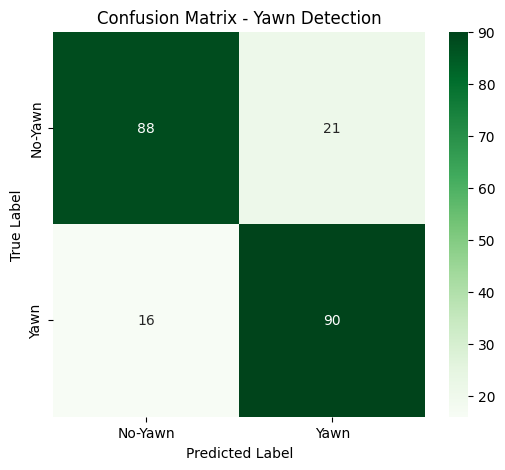

In [21]:
# Train simple threshold-based yawn classifier
from sklearn.tree import DecisionTreeClassifier

if len(X_train_yawn) > 0:
    yawn_model = DecisionTreeClassifier(max_depth=3, random_state=42)
    yawn_model.fit(X_train_yawn, y_train_yawn)

    # Evaluate
    y_pred_yawn = yawn_model.predict(X_test_yawn)
    yawn_accuracy = accuracy_score(y_test_yawn, y_pred_yawn)

    print("="*50)
    print("YAWN DETECTION MODEL PERFORMANCE")
    print("="*50)
    print(f"Test Accuracy: {yawn_accuracy * 100:.2f}%")
    print("="*50)

    print("\nClassification Report:")
    print(classification_report(y_test_yawn, y_pred_yawn, target_names=['No-Yawn', 'Yawn']))

    # Confusion Matrix
    cm_yawn = confusion_matrix(y_test_yawn, y_pred_yawn)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_yawn, annot=True, fmt='d', cmap='Greens',
                xticklabels=['No-Yawn', 'Yawn'],
                yticklabels=['No-Yawn', 'Yawn'])
    plt.title('Confusion Matrix - Yawn Detection')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
else:
    print("ERROR: No yawn features extracted")

# Test

In [22]:
# ========================================
# MANUAL TEST - VERIFY YAWN MODEL WORKS
# ========================================
print("\n" + "="*60)
print("MANUAL TESTING - YAWN MODEL")
print("="*60)

correct = 0
total = 10

for i in range(total):
    idx = np.random.randint(0, len(X_test_yawn))
    mar_value = X_test_yawn[idx][0]
    true_label = y_test_yawn[idx]
    pred_label = yawn_model.predict([[mar_value]])[0]

    true_str = "YAWN" if true_label == 1 else "NO-YAWN"
    pred_str = "YAWN" if pred_label == 1 else "NO-YAWN"

    if pred_label == true_label:
        match = " CORRECT"
        correct += 1
    else:
        match = " WRONG"

    print(f"Test {i+1}: MAR={mar_value:.3f} | True={true_str:8} | Pred={pred_str:8} | {match}")

accuracy = (correct / total) * 100
print(f"\nManual Test Accuracy: {correct}/{total} = {accuracy:.0f}%")

# Also print MAR statistics
print("\n" + "="*60)
print("MAR STATISTICS (Important!)")
print("="*60)
no_yawn_mar = X_test_yawn[y_test_yawn == 0]
yawn_mar = X_test_yawn[y_test_yawn == 1]

print(f"No-Yawn MAR range: {no_yawn_mar.min():.3f} - {no_yawn_mar.max():.3f}")
print(f"No-Yawn MAR mean:  {no_yawn_mar.mean():.3f}")
print(f"\nYawn MAR range:    {yawn_mar.min():.3f} - {yawn_mar.max():.3f}")
print(f"Yawn MAR mean:     {yawn_mar.mean():.3f}")

# Check if values are reasonable
if no_yawn_mar.mean() > 1.0:
    print("\n  WARNING: No-Yawn MAR values are TOO HIGH (>1.0)")
    print("  This means MAR calculation might be wrong")
    print("  Normal mouth should have MAR ~0.3-0.5")
elif yawn_mar.mean() < 0.6:
    print("\n  WARNING: Yawn MAR values are TOO LOW (<0.6)")
    print("  Yawning should have MAR ~0.6-0.8+")
else:
    print("\n MAR values look reasonable")

if accuracy >= 70:
    print(f"\n Yawn model is good Accuracy: {accuracy:.0f}%")
else:
    print(f"\n Yawn model is bad Accuracy: {accuracy:.0f}%")
    print("DO NOT SAVE - Need to fix MAR calculation or retrain")


MANUAL TESTING - YAWN MODEL
Test 1: MAR=0.489 | True=NO-YAWN  | Pred=NO-YAWN  |  CORRECT
Test 2: MAR=0.579 | True=NO-YAWN  | Pred=NO-YAWN  |  CORRECT
Test 3: MAR=0.603 | True=NO-YAWN  | Pred=NO-YAWN  |  CORRECT
Test 4: MAR=0.551 | True=NO-YAWN  | Pred=NO-YAWN  |  CORRECT
Test 5: MAR=0.688 | True=YAWN     | Pred=YAWN     |  CORRECT
Test 6: MAR=0.585 | True=NO-YAWN  | Pred=NO-YAWN  |  CORRECT
Test 7: MAR=0.617 | True=YAWN     | Pred=YAWN     |  CORRECT
Test 8: MAR=0.589 | True=YAWN     | Pred=YAWN     |  CORRECT
Test 9: MAR=0.496 | True=NO-YAWN  | Pred=NO-YAWN  |  CORRECT
Test 10: MAR=0.553 | True=NO-YAWN  | Pred=NO-YAWN  |  CORRECT

Manual Test Accuracy: 10/10 = 100%

MAR STATISTICS (Important!)
No-Yawn MAR range: 0.476 - 0.669
No-Yawn MAR mean:  0.559

Yawn MAR range:    0.497 - 0.883
Yawn MAR mean:     0.667

 MAR values look reasonable

 Yawn model is good Accuracy: 100%


## Yawn Model Visualization

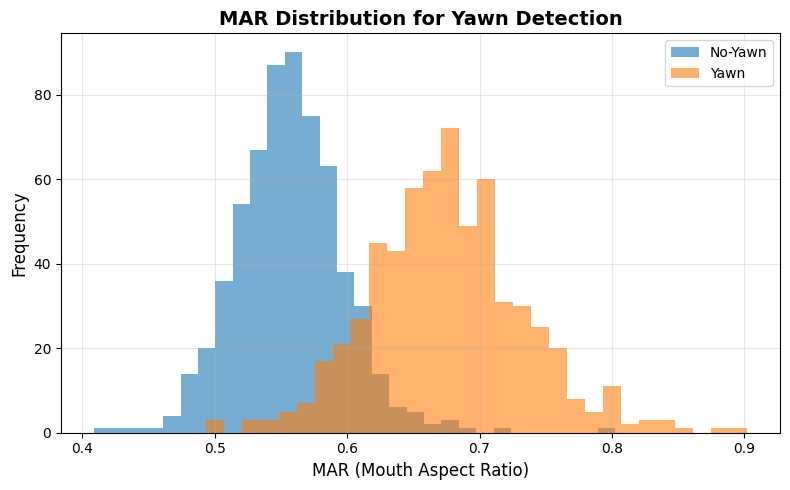


MAR Statistics:
No-Yawn - Mean: 0.5567, Std: 0.0401
Yawn - Mean: 0.6749, Std: 0.0583


In [23]:
plt.figure(figsize=(8, 5))

# MAR Distribution by Class
plt.hist(X_train_yawn[y_train_yawn == 0], bins=30, alpha=0.6,
         label='No-Yawn')
plt.hist(X_train_yawn[y_train_yawn == 1], bins=30, alpha=0.6,
         label='Yawn')

plt.xlabel('MAR (Mouth Aspect Ratio)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('MAR Distribution for Yawn Detection', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print MAR statistics
print("\nMAR Statistics:")
print(f"No-Yawn - Mean: {np.mean(X_train_yawn[y_train_yawn == 0]):.4f}, "
      f"Std: {np.std(X_train_yawn[y_train_yawn == 0]):.4f}")

print(f"Yawn - Mean: {np.mean(X_train_yawn[y_train_yawn == 1]):.4f}, "
      f"Std: {np.std(X_train_yawn[y_train_yawn == 1]):.4f}")

# Save Models

## Save both models

In [24]:
# Create save directory
MODEL_SAVE_PATH = '/content/drive/MyDrive/drowsiness_models'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Save eye CNN model
eye_model_path = os.path.join(MODEL_SAVE_PATH, 'eye_cnn_model.keras')
eye_model.save(eye_model_path)
print(f"Eye CNN model saved to: {eye_model_path}")

# Save yawn model
if len(X_train_yawn) > 0:
    yawn_model_path = os.path.join(MODEL_SAVE_PATH, 'yawn_model.pkl')
    with open(yawn_model_path, 'wb') as f:
        pickle.dump(yawn_model, f)
    print(f"Yawn model saved to: {yawn_model_path}")

# Save metadata
metadata = {
    'eye_model': {
        'type': 'CNN',
        'accuracy': eye_accuracy,
        'classes': ['Open', 'Closed']
    },
    'yawn_model': {
        'type': 'DecisionTree',
        'accuracy': yawn_accuracy if len(X_train_yawn) > 0 else 0,
        'feature': 'MAR',
        'classes': ['No-Yawn', 'Yawn']
    },
    'drowsiness_logic': {
        'eye_closure_threshold': '3 seconds',
        'yawn_threshold': 'MAR-based',
        'decision_rule': 'Eyes closed 3s OR Yawning = Drowsy'
    }
}

metadata_path = os.path.join(MODEL_SAVE_PATH, 'hybrid_metadata.pkl')
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)

print(f"Metadata saved to: {metadata_path}")
print("\nAll models saved successfully")

Eye CNN model saved to: /content/drive/MyDrive/drowsiness_models/eye_cnn_model.keras
Yawn model saved to: /content/drive/MyDrive/drowsiness_models/yawn_model.pkl
Metadata saved to: /content/drive/MyDrive/drowsiness_models/hybrid_metadata.pkl

All models saved successfully


# TEMPORAL LOGIC & FINAL DECISION

## Implement Temporal Logic for Real-Time Detection

In [25]:
class DrowsinessDetector:
    """
    Real-time drowsiness detector using temporal logic

    Rules:
    - Eyes closed for 3+ consecutive seconds - Drowsy
    - Yawning detected - Drowsy
    - Both conditions - High Alert
    """

    def __init__(self, eye_model, yawn_model, fps=30):
        self.eye_model = eye_model
        self.yawn_model = yawn_model
        self.fps = fps

        # Temporal tracking
        self.eye_closed_frames = 0
        self.eye_closure_threshold = 3 * fps  # 3 seconds worth of frames

        # Status
        self.is_drowsy = False
        self.drowsy_reason = []

    def predict_eye_state(self, eye_image):
        """Predict if eye is open or closed"""
        # Preprocess
        eye_img = cv2.resize(eye_image, (64, 64))
        eye_img = eye_img.astype('float32') / 255.0
        eye_img = np.expand_dims(eye_img, axis=0)

        # Predict
        pred = self.eye_model.predict(eye_img, verbose=0)[0][0]
        return 'Closed' if pred > 0.5 else 'Open'

    def predict_yawn(self, face_image):
        """Predict if person is yawning"""
        # Extract MAR
        rgb_image = cv2.cvtColor(face_image, cv2.COLOR_BGR2RGB)
        results = face_mesh_detector.process(rgb_image)

        if not results.multi_face_landmarks:
            return 'No-Yawn'

        landmarks = results.multi_face_landmarks[0].landmark
        h, w = face_image.shape[:2]
        mouth_points = [(landmarks[i].x * w, landmarks[i].y * h) for i in MOUTH]
        mar = calculate_mar(mouth_points)

        # Predict
        pred = self.yawn_model.predict([[mar]])[0]
        return 'Yawn' if pred == 1 else 'No-Yawn'

    def update(self, eye_image, face_image):
        """Update detector with new frame"""
        # Check eye state
        eye_state = self.predict_eye_state(eye_image)

        # Track eye closure duration
        if eye_state == 'Closed':
            self.eye_closed_frames += 1
        else:
            self.eye_closed_frames = 0

        # Check yawn
        yawn_state = self.predict_yawn(face_image)

        # Determine drowsiness
        self.drowsy_reason = []

        # Rule 1: Eyes closed for 3+ seconds
        if self.eye_closed_frames >= self.eye_closure_threshold:
            self.drowsy_reason.append("Eyes closed for 3+ seconds")

        # Rule 2: Yawning
        if yawn_state == 'Yawn':
            self.drowsy_reason.append("Yawning detected")

        # Final decision
        self.is_drowsy = len(self.drowsy_reason) > 0

        return {
            'eye_state': eye_state,
            'yawn_state': yawn_state,
            'eye_closed_duration': self.eye_closed_frames / self.fps,
            'is_drowsy': self.is_drowsy,
            'reason': self.drowsy_reason
        }

print("Drowsiness Detector class created")
print("\nUsage for real-time detection:")
print("detector = DrowsinessDetector(eye_model, yawn_model)")
print("result = detector.update(eye_frame, full_face_frame)")
print("if result['is_drowsy']: print('ALERT: Drowsy')")

Drowsiness Detector class created

Usage for real-time detection:
detector = DrowsinessDetector(eye_model, yawn_model)
result = detector.update(eye_frame, full_face_frame)
if result['is_drowsy']: print('ALERT: Drowsy')
